# 05 · Error analysis - where and how often the model is wrong

Data: walk-forward out-of-fold predictions of the shipped configuration (Jul 2025 – Mar 2026, 6,365 orders; each fold scored by a model that never saw it), calibrated. The Apr–Jun 2026 holdout appears only as the aggregates stored by its single run (`model_meta.json`); it is not re-scored. Operating point: **call if risk ≥ 13.7% (top 25%)**, from Phase 5.

In [1]:
import json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from kestrel.config import FIGURES_DIR, MODELS_DIR, ROOT
from kestrel.economics import Costs, realised_value
from kestrel.train import FINAL_CONFIG, SELECTION_END, FOLDS, FOLD_NAMES, load_training_frame, train_final, ranking_metrics

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
meta = json.loads((MODELS_DIR / "model_meta.json").read_text(encoding="utf-8"))
CUT = meta["decision"]["score_cutoff_for_call"]
X, y_all, ts, catalogue, pack = load_training_frame()
model_sel, oof = train_final(FINAL_CONFIG, X, y_all, ts, catalogue, end=SELECTION_END)
tr = pack["train"]
d = oof.copy()
d["p"] = model_sel.calibrator.transform(d.raw)
for c in ["family", "payment_mode", "shield", "promised_delivery_days", "customer_prior_returns", "customer_prior_orders", "discount_pct"]:
    d[c] = X[c].to_numpy()[d.index]
for c in ["sales_channel", "is_gift", "customer_id", "order_value_inr"]:
    d[c] = tr[c].to_numpy()[d.index]
d["ts"] = ts.to_numpy()[d.index]
d["month"] = d.ts.astype("datetime64[ns]").dt.to_period("M")
d["call"] = d.p >= CUT
# seen vs unseen: did the customer have an order in the fold's training window?
fold_start = {k: pd.Timestamp(a) for k, (a, b) in enumerate(FOLDS)}
first_order = tr.groupby("customer_id").order_ts.min()
d["seen"] = np.where(d.customer_id.map(first_order) < d.fold.map(fold_start), "seen in training", "new to the model")
d["history"] = np.where(d.customer_prior_orders == 0, "prior_orders = 0", "prior_orders > 0")
d["shield_s"] = np.where(d.shield == 1, "Shield", "not Shield")
d["gift"] = np.where(d.is_gift == "Y", "gift", "not gift")
scale = meta["decision"]["orders_per_month_in_export"] / len(d)
print(f"{len(d)} OOF orders | cutoff {CUT:.4f} | share called {d.call.mean():.3f} | pooled OOF AUC {roc_auc_score(d.y, d.p):.4f}")

6365 OOF orders | cutoff 0.1365 | share called 0.250 | pooled OOF AUC 0.7775


## 1 · At the operating point, in plain words

In [2]:
tp = int((d.call & (d.y == 1)).sum()); fp = int((d.call & (d.y == 0)).sum())
fn = int((~d.call & (d.y == 1)).sum()); tn = int((~d.call & (d.y == 0)).sum())
conf = pd.DataFrame({"returned": [tp, fn], "kept": [fp, tn]}, index=["called (risk ≥ cutoff)", "shipped without a call"])
per_month = (conf * scale).round(1)
print("over 9 months of unseen orders:"); display(conf)
print("per month at the export's volume:"); display(per_month)
calls_pm = (tp + fp) * scale
print(f"Of ~{calls_pm:.0f} calls/month: ~{tp * scale:.0f} reach a customer who would have returned, ~{fp * scale:.0f} reach one who wouldn't (false alarms).")
print(f"False alarm rate among calls: {fp / (tp + fp):.0%} -> cost ₹{fp * scale * 45:,.0f}/month in calls that change nothing (already inside the net figure).")
print(f"Returns not flagged: {fn / (tp + fn):.0%} of all returns ({fn * scale:.0f}/month). They are handled exactly as today - the model adds no cost there.")

over 9 months of unseen orders:


,returned,kept
called (risk ≥ cutoff),435,1156
shipped without a call,276,4498


per month at the export's volume:


,returned,kept
called (risk ≥ cutoff),47.8,127.0
shipped without a call,30.3,494.0


Of ~175 calls/month: ~48 reach a customer who would have returned, ~127 reach one who wouldn't (false alarms).
False alarm rate among calls: 73% -> cost ₹5,713/month in calls that change nothing (already inside the net figure).
Returns not flagged: 39% of all returns (30/month). They are handled exactly as today - the model adds no cost there.


**Reading: how often it is wrong, at the operating point.** Per month at the export's volume, ~175 calls:
- ~**48** reach a customer who would have returned (27%). The 35% prevention applies to these.
- ~**127** are **false alarms (73%)**. They cost ₹45 each (~₹5,700/month) and change nothing for the customer, apart from a courtesy call. That cost is already inside the net figure.
- ~**30 returns/month (39% of all returns)** are not flagged. They are handled exactly as today; the model adds no cost there.

A 73% false-alarm rate is acceptable *only because the action is a ₹45 call*. Under Ritu's hold, each of those 127 would carry a 12% cancellation risk, which is the arithmetic behind "holding loses money".

## 2 · Stability over time

In [3]:
fold_tbl = pd.DataFrame({FOLD_NAMES[k]: ranking_metrics(g.y, d.loc[g.index, "p"]) for k, g in d.groupby("fold")}).T
fold_tbl.loc["Apr-Jun 26 (holdout, stored)"] = pd.Series(meta["metrics"]["holdout_apr_jun_2026"])
display(fold_tbl[["orders", "base_rate", "roc_auc", "pr_auc", "brier", "precision_top10", "recall_top20"]].round(3))
monthly = d.groupby("month").apply(lambda g: pd.Series({"orders": len(g), "return_rate": g.y.mean(), "auc": roc_auc_score(g.y, g.p),
                                                        "pred_rate": g.p.mean(), "precision_at_cutoff": g.y[g.call].mean(),
                                                        "share_called": g.call.mean()}), include_groups=False).round(3)
print(f"monthly AUC: min {monthly.auc.min():.3f}, max {monthly.auc.max():.3f}, sd {monthly.auc.std():.3f} (each month ~700 orders, ~80 returns)")
monthly

,orders,base_rate,roc_auc,pr_auc,brier,precision_top10,recall_top20
Jul-Sep 25,2157.0,0.111,0.800,0.419,0.080,0.458,0.565
Oct-Dec 25,2082.0,0.108,0.770,0.344,0.084,0.370,0.560
Jan-Mar 26,2126.0,0.116,0.766,0.376,0.088,0.404,0.534
"Apr-Jun 26 (holdout, stored)",2126.0,0.115,0.787,0.421,0.084,0.437,0.576


monthly AUC: min 0.741, max 0.821, sd 0.029 (each month ~700 orders, ~80 returns)


,orders,return_rate,auc,pred_rate,precision_at_cutoff,share_called
month,,,,,,
2025-07,736.0,0.118,0.781,0.127,0.278,0.269
2025-08,714.0,0.129,0.809,0.114,0.322,0.244
2025-09,707.0,0.085,0.821,0.122,0.210,0.283
2025-10,700.0,0.116,0.772,0.104,0.308,0.227
2025-11,698.0,0.106,0.741,0.105,0.249,0.248
2025-12,684.0,0.102,0.797,0.105,0.300,0.219
2026-01,719.0,0.113,0.758,0.111,0.259,0.257
2026-02,664.0,0.128,0.797,0.113,0.326,0.264
2026-03,743.0,0.109,0.743,0.104,0.226,0.238


**Reading: stable.** Fold AUC 0.766–0.800 and holdout 0.787. Monthly AUC (~700 orders, ~80 returns each) ranges **0.741–0.821** (sd 0.029), with no downward drift. Predicted vs actual monthly rates stay within ~3 points; the largest gap is Sep 2025 (12.2% predicted vs 8.5% actual, the lowest-return month in the data). The share called per month stays at 22–28%, so the 13.7% cutoff behaves like "top ~25%" month to month.

## 3 · Segment performance

In [4]:
rng = np.random.default_rng(0)
def seg_row(g):
    aucs = []
    for _ in range(200):
        k = rng.integers(0, len(g), len(g)); yy, pp = g.y.to_numpy()[k], g.p.to_numpy()[k]
        if 0 < yy.sum() < len(yy): aucs.append(roc_auc_score(yy, pp))
    called = g[g.call]
    return pd.Series({"orders": len(g), "return_rate": g.y.mean(), "predicted_rate": g.p.mean(),
                      "auc": roc_auc_score(g.y, g.p) if 0 < g.y.sum() < len(g) else np.nan,
                      "auc_lo": np.percentile(aucs, 2.5), "auc_hi": np.percentile(aucs, 97.5),
                      "share_called": g.call.mean(), "precision_when_called": called.y.mean() if len(called) else np.nan,
                      "recall": (g.call & (g.y == 1)).sum() / max(g.y.sum(), 1)})
SEGMENTS = {"customer seen in training?": "seen", "CRM history": "history", "Shield": "shield_s", "family": "family",
            "payment mode": "payment_mode", "channel": "sales_channel", "gift": "gift"}
seg = pd.concat({name: d.groupby(col).apply(seg_row, include_groups=False) for name, col in SEGMENTS.items()})
seg["calibration_gap_pts"] = (seg.return_rate - seg.predicted_rate) * 100
seg.round(3)

orders  return_rate  predicted_rate    auc  auc_lo  auc_hi  share_called  precision_when_called  recall  calibration_gap_pts
customer seen in training? new to the model   4077.0        0.113           0.111  0.781   0.762   0.803         0.246                  0.281   0.614                0.112
                           seen in training   2288.0        0.110           0.112  0.771   0.741   0.801         0.257                  0.260   0.607               -0.199
CRM history                prior_orders = 0   1794.0        0.091           0.085  0.745   0.704   0.784         0.185                  0.227   0.457                0.676
                           prior_orders > 0   4571.0        0.120           0.122  0.787   0.768   0.809         0.276                  0.286   0.658               -0.266
Shield                     Shield             1391.0        0.179           0.179  0.764   0.728   0.797         0.482                  0.296   0.795                0.045
                           not Shield         4974.0        0.093           0.093  0.767   0.746   0.787         0.185                  0.257   0.513               -0.013
family                     Air Fryer           909.0        0.117           0.128  0.746   0.687   0.802         0.303                  0.265   0.689               -1.106
                           Ceiling Fan         916.0        0.060           0.069  0.828   0.778   0.874         0.115                  0.267   0.509               -0.923
                           Induction Cooktop   936.0        0.077           0.070  0.767   0.709   0.828         0.112                  0.276   0.403                0.690
                           Mixer Grinder       865.0        0.062           0.068  0.764   0.691   0.825         0.106                  0.207   0.352               -0.594
                           Robot Vacuum        923.0        0.212           0.179  0.726   0.689   0.763         0.476                  0.319   0.714                3.360
                           Room Heater         937.0        0.108           0.109  0.724   0.674   0.777         0.245                  0.239   0.545               -0.122
                           Water Purifier      879.0        0.144           0.159  0.754   0.709   0.801         0.392                  0.264   0.717               -1.445
payment mode               cod                1891.0        0.182           0.180  0.741   0.708   0.769         0.494                  0.281   0.762                0.241
                           emi                 753.0        0.076           0.096  0.771   0.710   0.833         0.178                  0.216   0.509               -2.022
                           prepaid_card       1298.0        0.091           0.088  0.742   0.693   0.790         0.161                  0.254   0.449                0.308
                           prepaid_upi        2423.0        0.079           0.076  0.773   0.739   0.812         0.130                  0.290   0.474                0.275
channel                    app                2196.0        0.100           0.113  0.778   0.741   0.810         0.261                  0.240   0.630               -1.343
                           marketplace        1734.0        0.133           0.111  0.768   0.738   0.804         0.245                  0.311   0.571                2.223
                           partner_outlet      779.0        0.091           0.118  0.831   0.768   0.876         0.267                  0.269   0.789               -2.732
                           web                1656.0        0.115           0.107  0.773   0.740   0.810         0.232                  0.283   0.574                0.738
gift                       gift                441.0        0.177           0.105  0.792   0.725   0.848         0.222                  0.469   0.590                7.192
                           not gift           5924.0        0.107           0.112  0.778   0.759   0.794         

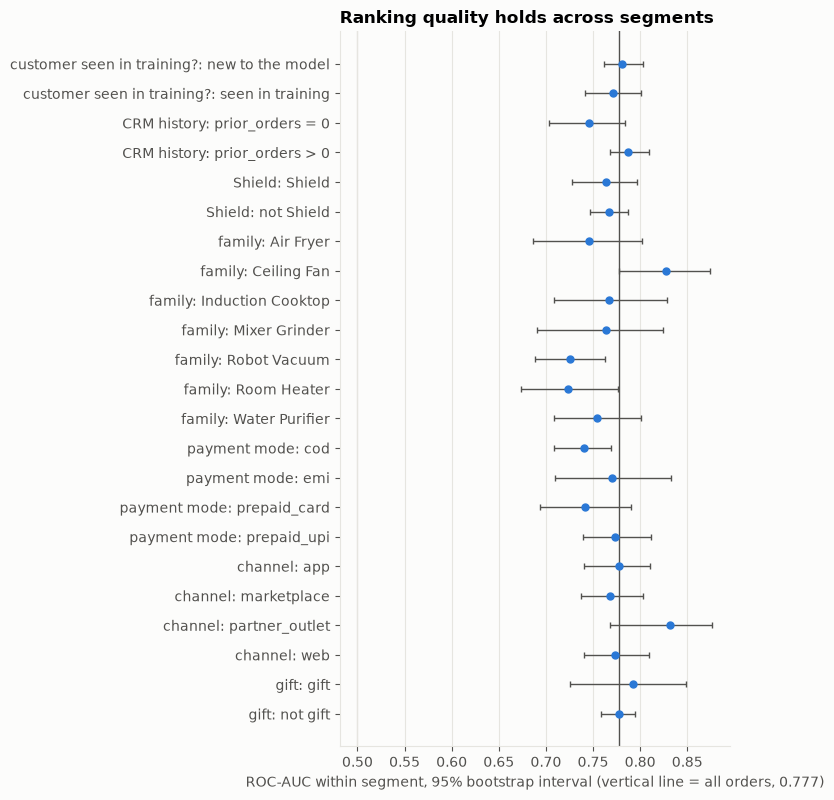

In [5]:
BLUE, ORANGE, INK, INK2, GRID, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False})
pooled = roc_auc_score(d.y, d.p)
s = seg.reset_index().rename(columns={"level_0": "group", "level_1": "segment"})
s["label"] = s.group + ": " + s.segment.astype(str)
s = s.iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 0.3 * len(s) + 1.2))
ax.errorbar(s.auc, s.label, xerr=[s.auc - s.auc_lo, s.auc_hi - s.auc], fmt="o", color=BLUE, ecolor=INK2, elinewidth=1, capsize=2, ms=5)
ax.axvline(pooled, color=INK2, lw=1); ax.axvline(0.5, color=GRID, lw=1)
ax.set_xlabel(f"ROC-AUC within segment, 95% bootstrap interval (vertical line = all orders, {pooled:.3f})"); ax.grid(axis="y", visible=False)
ax.set_title("Ranking quality holds across segments", loc="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "05_segment_auc.png", dpi=150); plt.show()

**Reading: segments.**
- **New vs seen customers: no weakness.** Customers the model never saw in training: AUC 0.781; seen: 0.771. Expected, because the model uses CRM history fields, not customer identity.
- **`prior_orders = 0` (no CRM history) is the weakest group:** AUC **0.745** [0.704, 0.784] vs 0.787, and recall at the cutoff is only **46%** (vs 66%). With no history, the model has only product, payment, delivery and discount to go on.
- **Shield:** same ranking quality (0.764 vs 0.767) and calibration (gap < 0.1 pt). 48% of Shield orders are called vs 19% of others: higher risk, not bias.
- **Family:** ranking is weakest for room heaters (0.724) and robot vacuums (0.726). **Robot vacuums are under-predicted by 3.4 points** (21.2% actual vs 17.9% predicted), consistent with their rising return rate (Phase 2 drift).
- **Channel (not in the model):** partner-outlet orders are **over-predicted by 2.7 pts**, marketplace **under-predicted by 2.2 pts**. Channel passed the selection rule on only 1 of 3 folds, so it stays out; recorded as a limitation.
- **Payment:** EMI over-predicted by 2.0 pts; others within 0.3.

## 4 · Calibration, and gift orders (known limitation)

In [6]:
d["decile"] = pd.qcut(d.p, 10, labels=False)
rel = d.groupby("decile").agg(predicted=("p", "mean"), actual=("y", "mean"), orders=("y", "size")).round(3)
display(rel)
g = d.groupby("gift").agg(orders=("y", "size"), predicted=("p", "mean"), actual=("y", "sum"))
g["actual"] = g.actual / g.orders
g["ratio_actual_to_predicted"] = g.actual / g.predicted
display(g.round(3))
gift = d[d.gift == "gift"]
ratio = float(g.loc["gift", "ratio_actual_to_predicted"])
gap_pts = float(g.loc["gift", "actual"] - g.loc["gift", "predicted"]) * 100
# rough ₹ effect: gift orders below the cutoff whose risk, scaled by the observed gift ratio, would clear it
p_adj = (gift.p * ratio).clip(upper=0.99)
missed = gift[(gift.p < CUT) & (p_adj >= CUT)]
gain_each = 0.35 * p_adj[missed.index] * 1150 - 45
print(f"gift orders: {len(gift)} ({len(gift) / len(d):.1%}); predicted {g.loc['gift', 'predicted']:.3f} vs actual {g.loc['gift', 'actual']:.3f} -> under-predicted by {gap_pts:.1f} pts (x{ratio:.2f})")
print(f"gift orders below the cutoff that a gift-aware score would call: {len(missed)} over 9 months = {len(missed) * scale:.1f}/month")
print(f"rough value of calling them: ₹{gain_each.sum() * scale:,.0f}/month (expected), vs ₹{realised_value(d.y, d.order_value_inr, d.call, 'call')['net'] * scale:,.0f}/month total policy value")
print(f"already-called gift orders: {gift.call.mean():.0%} of gift orders; their precision {gift.y[gift.call].mean():.3f}")

,predicted,actual,orders
decile,,,
0,0.017,0.013,637
1,0.027,0.027,636
2,0.037,0.042,637
3,0.049,0.047,636
4,0.062,0.066,637
5,0.080,0.088,636
6,0.104,0.101,636
7,0.138,0.116,637
8,0.197,0.211,636


,orders,predicted,actual,ratio_actual_to_predicted
gift,,,,
gift,441,0.105,0.177,1.685
not gift,5924,0.112,0.107,0.952


gift orders: 441 (6.9%); predicted 0.105 vs actual 0.177 -> under-predicted by 7.2 pts (x1.69)
gift orders below the cutoff that a gift-aware score would call: 89 over 9 months = 9.8/month
rough value of calling them: ₹264/month (expected), vs ₹11,365/month total policy value
already-called gift orders: 22% of gift orders; their precision 0.469


**Reading:**
- **Overall calibration is tight:** deciles from 1.7% to 40.6% predicted vs 1.3% to 40.7% actual.
- **Gift orders, known limitation:** the model has no gift feature (it missed the selection bar by a hair in Phase 4). On the walk-forward predictions, gift orders are **under-predicted by 7.2 points** (10.5% predicted vs 17.7% actual, ×1.69). Rough ₹ effect: scaling gift risk by the observed ratio would move **~10 gift orders/month** above the cutoff, worth **~₹260/month** in expected net value, **about 2% of the policy's ₹11,400/month**. Small, because gifts are 7% of orders and 22% of them are already called (precision 47%). Recorded as a known limitation, and a cheap future fix (add the gift flag, or a gift uplift, once more data confirms it).

## 5 · Failure gallery (anonymised: no IDs, no notes, no pincodes)

In [7]:
cols = ["family", "payment_mode", "promised_delivery_days", "customer_prior_returns", "customer_prior_orders", "shield", "discount_pct", "gift", "p", "y"]
false_alarms = d[d.y == 0].sort_values("p", ascending=False).head(5)[cols]
missed_ret = d[d.y == 1].sort_values("p").head(5)[cols]
print("Confident false alarms (highest risk, kept the product):"); display(false_alarms.round(3).reset_index(drop=True))
print("Confident misses (lowest risk, returned anyway):"); display(missed_ret.round(3).reset_index(drop=True))
print("Returned orders the model scored below 5%:", int(((d.y == 1) & (d.p < 0.05)).sum()), "of", int(d.y.sum()),
      f"({((d.y == 1) & (d.p < 0.05)).sum() / d.y.sum():.0%}); return rate in that band {d[d.p < 0.05].y.mean():.3f}")

Confident false alarms (highest risk, kept the product):


,family,payment_mode,promised_delivery_days,customer_prior_returns,customer_prior_orders,shield,discount_pct,gift,p,y
0,Air Fryer,cod,11.0,4.0,4.0,0.0,7.0,not gift,0.919,0
1,Water Purifier,prepaid_upi,5.0,4.0,5.0,1.0,4.0,not gift,0.819,0
2,Water Purifier,cod,5.0,3.0,4.0,0.0,14.0,not gift,0.803,0
3,Water Purifier,prepaid_upi,6.0,3.0,5.0,1.0,12.0,not gift,0.788,0
4,Water Purifier,cod,5.0,2.0,4.0,1.0,3.0,not gift,0.780,0


Confident misses (lowest risk, returned anyway):


,family,payment_mode,promised_delivery_days,customer_prior_returns,customer_prior_orders,shield,discount_pct,gift,p,y
0,Ceiling Fan,prepaid_upi,2.0,0.0,3.0,0.0,2.0,gift,0.008,1
1,Induction Cooktop,prepaid_upi,4.0,0.0,2.0,0.0,8.0,not gift,0.015,1
2,Induction Cooktop,prepaid_upi,5.0,0.0,0.0,0.0,8.0,not gift,0.017,1
3,Mixer Grinder,prepaid_upi,4.0,0.0,2.0,0.0,13.0,not gift,0.020,1
4,Mixer Grinder,prepaid_upi,1.0,0.0,0.0,1.0,7.0,not gift,0.020,1


Returned orders the model scored below 5%: 72 of 711 (10%); return rate in that band 0.031


**Reading: failures look like what they are.**
- **Confident false alarms** are customers with 2–4 prior returns out of 4–5 orders (often on COD, often purifiers) who kept this one. The model's risk is right on average for that group (its top decile returns 40.7%), and individual cases still go either way. A call costs ₹45 and annoys no one.
- **Confident misses** are cheap, prepaid orders from customers with no prior returns (fans, cooktops, mixers on UPI). Nothing at dispatch distinguishes them. **10% of returns (72 of 711) were scored below 5%**; the return rate in that band is 3.1%. No dispatch-time model can catch these, so they are the floor of what is achievable, not a bug.

## 6 · Automated checks

In [8]:
res = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider"], cwd=ROOT, capture_output=True, text=True)
PYTEST = res.stdout.strip().splitlines()[-1]
print(PYTEST)

76 passed in 6.45s


**Summary for `evidence/backtest_report.md`:** works (AUC 0.77–0.80 on every unseen period, calibrated), fails predictably (73% of calls are false alarms at ₹45 each; 39% of returns not flagged; weakest for customers with no CRM history), with known limitations: gift (−7.2 pts, ~₹260/month), robot vacuums (−3.4 pts), channel (partner +2.7 / marketplace −2.2 pts), and reliance on a snapshot Shield field.